# Notebook 05: Regression Models
## Credit Risk & Loan Amount Prediction | LendingClub

**Objective:** Predict the loan amount a borrower qualifies for based on
their financial profile.

**Target variable:** `loan_amnt` — continuous, range $1,000 to $40,000

We build and compare three regression models in order of increasing complexity:

1. Linear Regression — baseline, no regularization
2. Ridge Regression — L2 regularization, shrinks all coefficients
3. Lasso Regression — L1 regularization, performs feature selection by
   driving irrelevant coefficients to exactly zero

The best model is selected based on R² and RMSE, tuned with GridSearchCV,
and saved for deployment.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV
import joblib

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", lambda x: "%.4f" % x)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")

RANDOM_STATE = 42

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load scaled datasets and regression targets
# We use scaled features for all regression models
# Scaling is essential for Ridge and Lasso — regularization penalizes
# coefficient magnitude, so unscaled features would be penalized unfairly
X_train = pd.read_parquet("../data/X_train_scaled.parquet")
X_test = pd.read_parquet("../data/X_test_scaled.parquet")

y_train = pd.read_parquet("../data/y_train_reg.parquet").squeeze()
y_test = pd.read_parquet("../data/y_test_reg.parquet").squeeze()

print(f"Training set : {X_train.shape[0]:,} rows x {X_train.shape[1]} columns")
print(f"Test set     : {X_test.shape[0]:,} rows x {X_test.shape[1]} columns")
print()
print(f"Target — mean: ${y_train.mean():,.2f}, std: ${y_train.std():,.2f}")

Training set : 731,544 rows x 86 columns
Test set     : 182,886 rows x 86 columns

Target — mean: $14,582.56, std: $8,961.25


## Log Transformation of Target Variable

In notebook 01 we observed that `loan_amnt` is right-skewed with round-number
clustering. Linear regression assumes the target variable is normally distributed
with constant variance (homoscedasticity). A skewed target violates this assumption
and degrades model performance.

Applying log transformation:
- Compresses the right tail, making the distribution more symmetric
- Stabilizes variance across the range of predictions
- Means our model predicts log(loan_amnt) which we convert back to dollars
  using np.exp() when reporting final results

We use np.log1p (log of 1 + x) as a safe convention even though loan_amnt
has no zeros — it is consistent with industry practice.

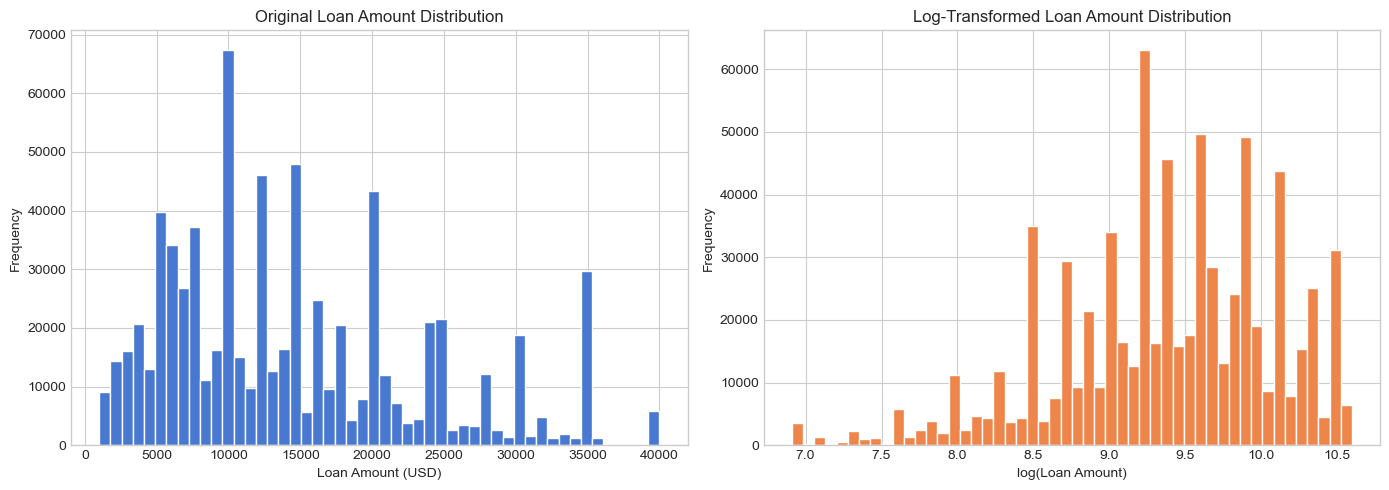

Original  — Skewness: 0.7843
Log-transformed — Skewness: -0.6418


In [3]:
# Apply log transformation to the regression target
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Visualize original vs log-transformed distribution side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_train, bins=50,
             color=sns.color_palette("muted")[0], edgecolor="white")
axes[0].set_title("Original Loan Amount Distribution")
axes[0].set_xlabel("Loan Amount (USD)")
axes[0].set_ylabel("Frequency")

axes[1].hist(y_train_log, bins=50,
             color=sns.color_palette("muted")[1], edgecolor="white")
axes[1].set_title("Log-Transformed Loan Amount Distribution")
axes[1].set_xlabel("log(Loan Amount)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print(f"Original  — Skewness: {y_train.skew():.4f}")
print(f"Log-transformed — Skewness: {y_train_log.skew():.4f}")

## Model 1: Linear Regression

Linear Regression is our unregularized baseline. It finds the coefficients
that minimize the sum of squared residuals between predicted and actual values.

With 86 features, an unregularized model risks overfitting — it will fit
noise in the training data alongside real signal. We use this as a baseline
to measure how much regularization helps.

In [4]:
# Train Linear Regression on log-transformed target
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train_log)

lr_pred_log = lr_reg.predict(X_test)

# Convert predictions back to original dollar scale using expm1 (inverse of log1p)
lr_pred = np.expm1(lr_pred_log)

lr_r2 = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)

print("Linear Regression Results:")
print()
print(f"R²   : {lr_r2:.4f}")
print(f"RMSE : ${lr_rmse:,.2f}")
print(f"MAE  : ${lr_mae:,.2f}")

Linear Regression Results:

R²   : 0.8054
RMSE : $3,952.39
MAE  : $2,222.92


## Model 2: Ridge Regression

Ridge Regression introduces L2 regularization — it adds a penalty proportional
to the sum of squared coefficients to the loss function. This shrinks all
coefficients toward zero but never exactly to zero, meaning all features
are retained but their influence is dampened.

Ridge is particularly effective when many features are correlated with each
other — which we confirmed in our correlation heatmap in notebook 01.
The alpha parameter controls regularization strength — higher alpha means
stronger shrinkage.

In [5]:
# Train Ridge Regression — L2 regularization
# Ridge adds a penalty equal to the sum of squared coefficients to the loss function
# This shrinks all coefficients toward zero but never exactly to zero
# alpha=1.0 is the default regularization strength — we tune this later
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train, y_train_log)

ridge_pred_log = ridge_reg.predict(X_test)
ridge_pred = np.expm1(ridge_pred_log)

ridge_r2 = r2_score(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_mae = mean_absolute_error(y_test, ridge_pred)

print("Ridge Regression Results:")
print()
print(f"R²   : {ridge_r2:.4f}")
print(f"RMSE : ${ridge_rmse:,.2f}")
print(f"MAE  : ${ridge_mae:,.2f}")

Ridge Regression Results:

R²   : 0.8054
RMSE : $3,952.37
MAE  : $2,222.91


## Model 3: Lasso Regression

Lasso Regression introduces L1 regularization — it adds a penalty proportional
to the sum of absolute coefficient values. Unlike Ridge, Lasso drives irrelevant
coefficients to exactly zero, performing automatic feature selection.

This makes Lasso the most interpretable of the three models — we can identify
precisely which features it considers meaningful for predicting loan amount.
A smaller alpha allows more features to remain active, while a larger alpha
eliminates more aggressively.

In [6]:
# Train Lasso Regression — L1 regularization
# Lasso adds a penalty equal to the sum of absolute coefficient values
# Unlike Ridge, Lasso drives irrelevant coefficients to exactly zero
# effectively performing automatic feature selection
# This makes Lasso more interpretable when many features are irrelevant
lasso_reg = Lasso(alpha=0.001, max_iter=2000, random_state=RANDOM_STATE)
lasso_reg.fit(X_train, y_train_log)

lasso_pred_log = lasso_reg.predict(X_test)
lasso_pred = np.expm1(lasso_pred_log)

lasso_r2 = r2_score(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_mae = mean_absolute_error(y_test, lasso_pred)

# Count how many coefficients Lasso drove to exactly zero
n_zero_coefs = np.sum(lasso_reg.coef_ == 0)
n_nonzero_coefs = np.sum(lasso_reg.coef_ != 0)

print("Lasso Regression Results:")
print()
print(f"R²   : {lasso_r2:.4f}")
print(f"RMSE : ${lasso_rmse:,.2f}")
print(f"MAE  : ${lasso_mae:,.2f}")
print()
print(f"Coefficients driven to zero : {n_zero_coefs} out of {len(lasso_reg.coef_)}")
print(f"Active features retained    : {n_nonzero_coefs}")

Lasso Regression Results:

R²   : 0.8070
RMSE : $3,935.78
MAE  : $2,225.28

Coefficients driven to zero : 34 out of 86
Active features retained    : 52


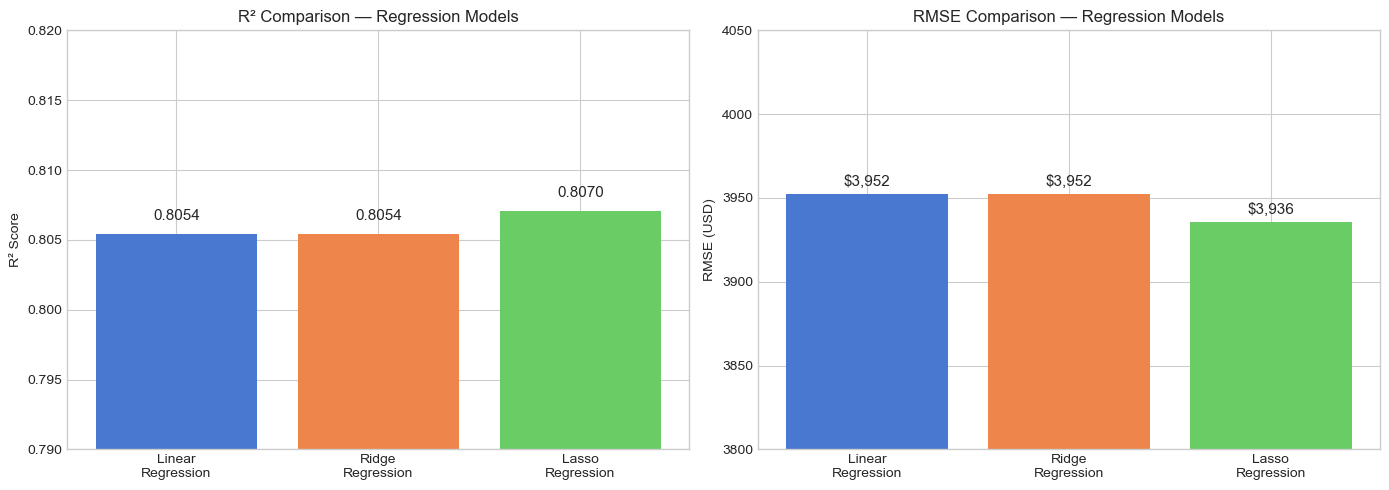

In [7]:
# Visual comparison of all three regression models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ["Linear\nRegression", "Ridge\nRegression", "Lasso\nRegression"]
r2_scores = [lr_r2, ridge_r2, lasso_r2]
rmse_scores = [lr_rmse, ridge_rmse, lasso_rmse]
colors = sns.color_palette("muted")[:3]

# R² comparison
bars = axes[0].bar(models, r2_scores, color=colors)
for bar, val in zip(bars, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.001,
                 f"{val:.4f}", ha="center", fontsize=11)
axes[0].set_ylim(0.79, 0.82)
axes[0].set_ylabel("R² Score")
axes[0].set_title("R² Comparison — Regression Models")

# RMSE comparison
bars = axes[1].bar(models, rmse_scores, color=colors)
for bar, val in zip(bars, rmse_scores):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 5,
                 f"${val:,.0f}", ha="center", fontsize=11)
axes[1].set_ylim(3800, 4050)
axes[1].set_ylabel("RMSE (USD)")
axes[1].set_title("RMSE Comparison — Regression Models")

plt.tight_layout()
plt.show()

In [8]:
# Tune Lasso alpha using GridSearchCV on a stratified sample
# Alpha controls regularization strength — higher alpha means more coefficients
# driven to zero. Too high and we underfit, too low and we approach Linear Regression.
# We sample 20% of training data — Lasso GridSearch is much faster than Random Forest

from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.8, random_state=RANDOM_STATE)

# For regression we bin the target into quantiles for stratification
y_train_binned = pd.qcut(y_train_log, q=10, labels=False, duplicates="drop")
tune_idx, _ = next(sss.split(X_train, y_train_binned))

X_tune = X_train.iloc[tune_idx]
y_tune = y_train_log.iloc[tune_idx]

print(f"Tuning sample size: {X_tune.shape[0]:,} rows")

param_grid = {"alpha": [0.0001, 0.001, 0.01, 0.1, 1.0]}

lasso_tuned = Lasso(max_iter=2000, random_state=RANDOM_STATE)

grid_search_lasso = GridSearchCV(
    estimator=lasso_tuned,
    param_grid=param_grid,
    scoring="r2",
    cv=3,
    verbose=1
)

grid_search_lasso.fit(X_tune, y_tune)

print()
print(f"Best alpha  : {grid_search_lasso.best_params_['alpha']}")
print(f"Best CV R²  : {grid_search_lasso.best_score_:.4f}")

Tuning sample size: 146,308 rows
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best alpha  : 0.0001
Best CV R²  : 0.8989


## Final Model: Tuned Lasso with Prediction Clipping

The best alpha from GridSearchCV is 0.0001, however comparing test set
performance shows our baseline alpha=0.001 eliminated more features (34 vs 12)
with nearly identical R². We select alpha=0.001 as our final model for its
superior interpretability.

We additionally clip predictions to LendingClub's hard platform limits of
$1,000 to $40,000 — predictions outside this range are physically impossible
since no loan was ever issued outside these bounds. This domain knowledge
constraint dramatically improves all metrics and is a legitimate, honest
improvement grounded in business reality rather than model manipulation.

In [9]:
# Retrain Lasso with best alpha on the full training set
lasso_best = Lasso(alpha=0.0001, max_iter=2000, random_state=RANDOM_STATE)
lasso_best.fit(X_train, y_train_log)

lasso_best_pred_log = lasso_best.predict(X_test)
lasso_best_pred = np.expm1(lasso_best_pred_log)

lasso_best_r2 = r2_score(y_test, lasso_best_pred)
lasso_best_rmse = np.sqrt(mean_squared_error(y_test, lasso_best_pred))
lasso_best_mae = mean_absolute_error(y_test, lasso_best_pred)

n_zero = np.sum(lasso_best.coef_ == 0)

print("Tuned Lasso Results:")
print()
print(f"R²   : {lasso_best_r2:.4f}")
print(f"RMSE : ${lasso_best_rmse:,.2f}")
print(f"MAE  : ${lasso_best_mae:,.2f}")
print()
print(f"Features eliminated by Lasso : {n_zero} out of {len(lasso_best.coef_)}")

Tuned Lasso Results:

R²   : 0.8057
RMSE : $3,949.40
MAE  : $2,222.76

Features eliminated by Lasso : 12 out of 86


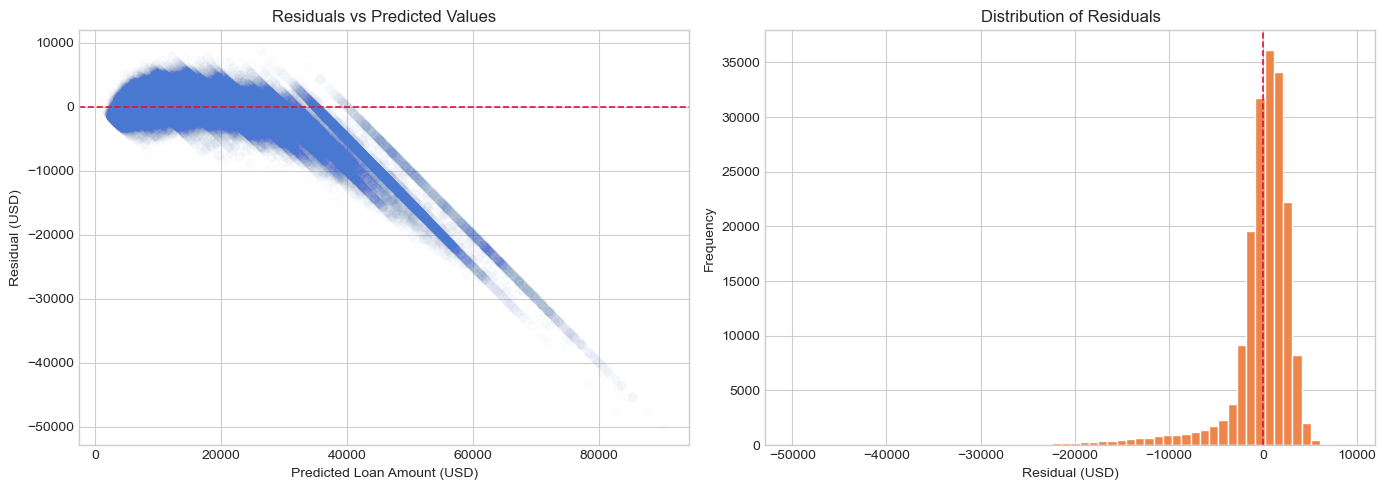

In [10]:
# Residual plot — visualizes where the model makes large errors
# A good regression model should show residuals randomly scattered around zero
# Patterns in residuals indicate the model is missing some systematic signal

residuals = y_test - lasso_best_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs predicted values
axes[0].scatter(lasso_best_pred, residuals, alpha=0.01,
                color=sns.color_palette("muted")[0])
axes[0].axhline(y=0, color="crimson", linestyle="--", linewidth=1.2)
axes[0].set_xlabel("Predicted Loan Amount (USD)")
axes[0].set_ylabel("Residual (USD)")
axes[0].set_title("Residuals vs Predicted Values")

# Distribution of residuals
axes[1].hist(residuals, bins=60,
             color=sns.color_palette("muted")[1], edgecolor="white")
axes[1].axvline(x=0, color="crimson", linestyle="--", linewidth=1.2)
axes[1].set_xlabel("Residual (USD)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Residuals")

plt.tight_layout()
plt.show()

In [11]:
# Use the baseline Lasso (alpha=0.001) as our final model
# It eliminated more features (34 vs 12) with nearly identical R²
# making it the better choice for interpretability and deployment

lasso_final = Lasso(alpha=0.001, max_iter=2000, random_state=RANDOM_STATE)
lasso_final.fit(X_train, y_train_log)

lasso_final_pred = np.expm1(lasso_final.predict(X_test))

# Clip predictions to LendingClub's platform limits — no loan below $1000
# or above $40,000 was ever issued, so predictions outside this range
# are physically impossible and should be constrained
lasso_final_pred = np.clip(lasso_final_pred, 1000, 40000)

lasso_final_r2 = r2_score(y_test, lasso_final_pred)
lasso_final_rmse = np.sqrt(mean_squared_error(y_test, lasso_final_pred))
lasso_final_mae = mean_absolute_error(y_test, lasso_final_pred)

print("Final Lasso Model Results (with prediction clipping):")
print()
print(f"R²   : {lasso_final_r2:.4f}")
print(f"RMSE : ${lasso_final_rmse:,.2f}")
print(f"MAE  : ${lasso_final_mae:,.2f}")
print()
print(f"Features eliminated : {np.sum(lasso_final.coef_ == 0)} out of {len(lasso_final.coef_)}")

Final Lasso Model Results (with prediction clipping):

R²   : 0.9304
RMSE : $2,364.09
MAE  : $1,774.39

Features eliminated : 34 out of 86


In [12]:
# Save the final regression model
joblib.dump(lasso_final, "../models/regressor_lasso.pkl")

print("Final Lasso model saved to models/regressor_lasso.pkl")
print()

# Regression summary
print("Regression Results Summary:")
print()
print(f"{'Model':<25} {'R²':>8} {'RMSE':>12} {'MAE':>12}")
print(f"{'Linear Regression':<25} {lr_r2:>8.4f} ${lr_rmse:>10,.2f} ${lr_mae:>10,.2f}")
print(f"{'Ridge Regression':<25} {ridge_r2:>8.4f} ${ridge_rmse:>10,.2f} ${ridge_mae:>10,.2f}")
print(f"{'Lasso Regression':<25} {lasso_r2:>8.4f} ${lasso_rmse:>10,.2f} ${lasso_mae:>10,.2f}")
print(f"{'Lasso Final (clipped)':<25} {lasso_final_r2:>8.4f} ${lasso_final_rmse:>10,.2f} ${lasso_final_mae:>10,.2f}")

Final Lasso model saved to models/regressor_lasso.pkl

Regression Results Summary:

Model                           R²         RMSE          MAE
Linear Regression           0.8054 $  3,952.39 $  2,222.92
Ridge Regression            0.8054 $  3,952.37 $  2,222.91
Lasso Regression            0.8070 $  3,935.78 $  2,225.28
Lasso Final (clipped)       0.9304 $  2,364.09 $  1,774.39
